<a href="https://colab.research.google.com/github/mathew-seby/avcs/blob/main/acvs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — INSTALL LIBRARIES & MOUNT GOOGLE DRIVE
# ============================================================

!pip install ultralytics --quiet
!pip install torch torchvision --quiet
!pip install pycocotools seaborn pandas --quiet
!git clone https://github.com/ultralytics/yolov5 /content/yolov5 -q
!pip install -r /content/yolov5/requirements.txt --quiet

import os, sys, time, glob, shutil, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
    ssd300_vgg16, SSD300_VGG16_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.ssd import SSDClassificationHead
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from ultralytics import YOLO
from google.colab import drive

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device     : {DEVICE}")
print(f"PyTorch    : {torch.__version__}")
print("✅ All libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Device     : cuda
PyTorch    : 2.10.0+cu128
✅ All libraries loaded


In [6]:
# ============================================================
# CELL 2 — DATASET SETUP (ZIP FILE VERSION)
# ============================================================

import os, shutil, glob, zipfile
from google.colab import drive

# ── UPDATE THESE TWO LINES ONLY ──
DRIVE_ZIP    = '/content/drive/MyDrive/Dataset/avcs_dataset.zip'  # your zip path
LOCAL_DATASET = '/content/AVCS_DATASET'                           # where to extract

# ROI
ROI = {'x1': 0.2484, 'y1': 0.5047, 'x2': 0.4813, 'y2': 0.7399}

# Class definitions
NC    = 2
NAMES = ['with_vehicle', 'without_vehicle']
EPOCHS = 50

# ── Step 1: Check zip exists ──
if not os.path.exists(DRIVE_ZIP):
    raise FileNotFoundError(f"Zip not found at: {DRIVE_ZIP}\nCheck the path and filename.")

print(f"✅ Zip found: {DRIVE_ZIP}")
print(f"   Size: {round(os.path.getsize(DRIVE_ZIP)/1e6, 1)} MB")

# ── Step 2: Extract zip ──
if os.path.exists(LOCAL_DATASET):
    shutil.rmtree(LOCAL_DATASET)
os.makedirs(LOCAL_DATASET, exist_ok=True)

print("Extracting zip — please wait...")
with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
    z.extractall(LOCAL_DATASET)
print(f"✅ Extracted to {LOCAL_DATASET}")

# ── Step 3: Auto-find dataset root ──
# Sometimes zip extracts into a subfolder — handle that
contents = os.listdir(LOCAL_DATASET)
print(f"   Contents after extract: {contents}")

# If zip created a single subfolder, go one level deeper
if len(contents) == 1 and os.path.isdir(f'{LOCAL_DATASET}/{contents[0]}'):
    LOCAL_DATASET = f'{LOCAL_DATASET}/{contents[0]}'
    print(f"   Auto-adjusted root to: {LOCAL_DATASET}")

# ── Step 4: Verify structure ──
print("\nDataset structure:")
found_splits = []
for split in ['train', 'valid', 'val', 'test']:
    img_path = f'{LOCAL_DATASET}/{split}/images'
    lbl_path = f'{LOCAL_DATASET}/{split}/labels'
    if os.path.exists(img_path):
        imgs = glob.glob(f'{img_path}/*.jpg') + glob.glob(f'{img_path}/*.png')
        lbls = glob.glob(f'{lbl_path}/*.txt') if os.path.exists(lbl_path) else []
        print(f"  {split:6s}: {len(imgs):4d} images | {len(lbls):4d} labels")
        found_splits.append(split)

if not found_splits:
    # Show what's actually inside so user can debug
    print("\n⚠️  Expected folders not found. Showing full extracted structure:")
    for root, dirs, files in os.walk(LOCAL_DATASET):
        level = root.replace(LOCAL_DATASET, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 3:
            for f in files[:3]:
                print(f"{indent}  {f}")
    raise RuntimeError("Could not find train/valid/test folders. Check structure above.")

# ── Step 5: Handle 'val' vs 'valid' naming ──
# YOLOv5/v8 expects 'valid' — rename 'val' if needed
val_path   = f'{LOCAL_DATASET}/val'
valid_path = f'{LOCAL_DATASET}/valid'
if os.path.exists(val_path) and not os.path.exists(valid_path):
    os.rename(val_path, valid_path)
    print("\n  Renamed val/ → valid/ for compatibility")

# ── Step 6: Create data.yaml ──
yaml_path = f'{LOCAL_DATASET}/data.yaml'
yaml_content = f"""path: {LOCAL_DATASET}
train: train/images
val:   valid/images
test:  test/images
nc: {NC}
names: {NAMES}
"""
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"\n✅ data.yaml created")
print(yaml_content)

# ── Global results store ──
ALL_RESULTS = {}
print(f"✅ Setup complete | {NC} classes | {EPOCHS} epochs | ROI={ROI}")

✅ Zip found: /content/drive/MyDrive/Dataset/avcs_dataset.zip
   Size: 70.1 MB
Extracting zip — please wait...
✅ Extracted to /content/AVCS_DATASET
   Contents after extract: ['avcs_dataset']
   Auto-adjusted root to: /content/AVCS_DATASET/avcs_dataset

Dataset structure:
  train : 1400 images | 1400 labels
  valid :  300 images |  300 labels
  test  :  300 images |  300 labels

✅ data.yaml created
path: /content/AVCS_DATASET/avcs_dataset
train: train/images
val:   valid/images
test:  test/images
nc: 2
names: ['with_vehicle', 'without_vehicle']

✅ Setup complete | 2 classes | 50 epochs | ROI={'x1': 0.2484, 'y1': 0.5047, 'x2': 0.4813, 'y2': 0.7399}


In [7]:
# ============================================================
# CELL 3 — SHARED UTILITIES
# Dataset class, metrics, helpers — used by all 4 models
# ============================================================

class AVCSDataset(Dataset):
    """
    Reads YOLO-format labels.
    class 0 = with_vehicle  (has boxes)
    class 1 = without_vehicle (empty label file)
    """
    def __init__(self, split='train'):
        self.imgs = sorted(
            glob.glob(f'{LOCAL_DATASET}/{split}/images/*.jpg') +
            glob.glob(f'{LOCAL_DATASET}/{split}/images/*.png')
        )

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img  = Image.open(img_path).convert('RGB')
        W, H = img.size

        lbl_path = (img_path
                    .replace('/images/', '/labels/')
                    .replace('.jpg', '.txt')
                    .replace('.png', '.txt'))

        boxes, labels = [], []
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    p = list(map(float, line.strip().split()))
                    if not p: continue
                    cls, xc, yc, bw, bh = p
                    # Only keep boxes inside ROI
                    if not (ROI['x1'] <= xc <= ROI['x2'] and
                            ROI['y1'] <= yc <= ROI['y2']):
                        continue
                    x1 = (xc - bw/2)*W;  y1 = (yc - bh/2)*H
                    x2 = (xc + bw/2)*W;  y2 = (yc + bh/2)*H
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls) + 1)   # +1 because 0 = background

        if boxes:
            boxes  = torch.tensor(boxes,  dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area   = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
        else:
            boxes  = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,),  dtype=torch.int64)
            area   = torch.zeros((0,),  dtype=torch.float32)

        target = {
            'boxes'   : boxes,
            'labels'  : labels,
            'image_id': torch.tensor([idx]),
            'area'    : area,
            'iscrowd' : torch.zeros(len(labels), dtype=torch.int64)
        }
        return T.ToTensor()(img), target


def collate_fn(batch):
    return tuple(zip(*batch))


def compute_iou(b1, b2):
    ix1 = max(b1[0], b2[0]);  iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]);  iy2 = min(b1[3], b2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def compute_metrics(all_preds, all_tgts, iou_thresh=0.5, conf_thresh=0.5):
    """Returns mAP@0.5, Precision, Recall, and confusion matrix values."""
    tp_l, fp_l, sc_l, n_gt = [], [], [], 0
    TP = FP = FN = TN = 0

    for preds, tgts in zip(all_preds, all_tgts):
        gt       = tgts['boxes'].cpu().numpy()
        scores   = preds['scores'].cpu().numpy()
        pb_all   = preds['boxes'].cpu().numpy()
        n_gt    += len(gt)

        # ── mAP computation ──
        matched = [False]*len(gt)
        for i in np.argsort(-scores):
            best_iou, best_j = 0, -1
            for j, gb in enumerate(gt):
                iou = compute_iou(pb_all[i], gb)
                if iou > best_iou: best_iou, best_j = iou, j
            if best_iou >= iou_thresh and best_j >= 0 and not matched[best_j]:
                tp_l.append(1); fp_l.append(0); matched[best_j] = True
            else:
                tp_l.append(0); fp_l.append(1)
            sc_l.append(scores[i])

        # ── Confusion matrix ──
        mask = scores >= conf_thresh
        pb   = pb_all[mask]
        matched2 = [False]*len(gt)
        for p in pb:
            best, bj = 0, -1
            for j, g in enumerate(gt):
                iou = compute_iou(p, g)
                if iou > best: best, bj = iou, j
            if best >= iou_thresh and bj >= 0 and not matched2[bj]:
                TP += 1; matched2[bj] = True
            else:
                FP += 1
        FN += matched2.count(False)
        if len(gt) == 0 and len(pb) == 0: TN += 1

    # ── Compute mAP ──
    if not sc_l or n_gt == 0:
        return 0.0, 0.0, 0.0, np.array([[0,0],[0,0]])

    order  = np.argsort(-np.array(sc_l))
    tp_cum = np.cumsum(np.array(tp_l)[order])
    fp_cum = np.cumsum(np.array(fp_l)[order])
    prec   = tp_cum / (tp_cum + fp_cum + 1e-6)
    rec    = tp_cum / (n_gt + 1e-6)
    p_full = np.concatenate([[1], prec, [0]])
    r_full = np.concatenate([[0], rec,  [1]])
    for i in range(len(p_full)-2, -1, -1):
        p_full[i] = max(p_full[i], p_full[i+1])
    idx  = np.where(r_full[1:] != r_full[:-1])[0]
    mAP  = float(np.sum((r_full[idx+1]-r_full[idx]) * p_full[idx+1]))
    P    = float(prec[-1]) if len(prec) else 0.0
    R    = float(rec[-1])  if len(rec)  else 0.0
    CM   = np.array([[TP, FP], [FN, TN]])

    return mAP, P, R, CM


def measure_fps(model, loader, n_batches=30):
    model.eval(); times = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches: break
            imgs = [x.to(DEVICE) for x in imgs]
            if DEVICE.type == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(imgs)
            if DEVICE.type == 'cuda': torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    ms = np.mean(times) * 1000
    return round(1000/ms, 2), round(ms, 2)


def model_mb(path):
    return round(os.path.getsize(path)/1e6, 2) if os.path.exists(path) else 0.0


# ── Shared test data for PyTorch models ──
train_ds = AVCSDataset('train')
test_ds  = AVCSDataset('test')
train_ld = DataLoader(train_ds, batch_size=4, shuffle=True,
                      collate_fn=collate_fn, num_workers=2)
test_ld  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                      collate_fn=collate_fn)

# ── YOLO test image list ──
test_imgs = (glob.glob(f'{LOCAL_DATASET}/test/images/*.jpg') +
             glob.glob(f'{LOCAL_DATASET}/test/images/*.png'))

print(f"✅ Utilities ready")
print(f"   Train: {len(train_ds)} | Test: {len(test_ds)} images")

✅ Utilities ready
   Train: 1400 | Test: 300 images


In [8]:
# ============================================================
# CELL 4 — TRAIN MODEL 1: YOLOv8n
# ============================================================
print("="*55)
print("  MODEL 1: YOLOv8n")
print("="*55)

m_v8 = YOLO('yolov8n.pt')
m_v8.train(
    data     = yaml_path,
    epochs   = EPOCHS,
    imgsz    = 640,
    batch    = 16,
    name     = 'yolov8_avcs',
    project  = '/content/runs',
    patience = 10,
    device   = 0 if torch.cuda.is_available() else 'cpu',
    verbose  = False
)

best_v8   = '/content/runs/yolov8_avcs/weights/best.pt'
m_v8_best = YOLO(best_v8)
v8_val    = m_v8_best.val(data=yaml_path, split='test', verbose=False)

# FPS
t0 = time.perf_counter()
for p in test_imgs[:50]: m_v8_best(p, verbose=False)
t1 = time.perf_counter()
n  = min(50, len(test_imgs))
v8_fps = round(n/(t1-t0), 2)
v8_ms  = round((t1-t0)/n*1000, 2)

# Collect predictions for confusion matrix
preds_v8, tgts_v8 = [], []
for i in range(len(test_ds)):
    img, tgt = test_ds[i]
    res = m_v8_best(test_ds.imgs[i], verbose=False)[0]
    boxes  = res.boxes.xyxy.cpu() if len(res.boxes) else torch.zeros((0,4))
    scores = res.boxes.conf.cpu() if len(res.boxes) else torch.zeros(0)
    preds_v8.append({'boxes': boxes, 'scores': scores})
    tgts_v8.append(tgt)

v8_map, v8_prec, v8_rec, v8_cm = compute_metrics(preds_v8, tgts_v8)

ALL_RESULTS['YOLOv8'] = {
    'mAP50'       : round(float(v8_val.box.map50), 4),
    'mAP50_95'    : round(float(v8_val.box.map),   4),
    'Precision'   : round(float(v8_val.box.mp),     4),
    'Recall'      : round(float(v8_val.box.mr),     4),
    'FPS'         : v8_fps,
    'Inference_ms': v8_ms,
    'Model_MB'    : model_mb(best_v8),
    'CM'          : v8_cm
}
print("\n✅ YOLOv8 complete:")
for k,v in ALL_RESULTS['YOLOv8'].items():
    if k != 'CM': print(f"   {k:15s}: {v}")

  MODEL 1: YOLOv8n
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AVCS_DATASET/avcs_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_avcs, nbs=64, nms=False, opset=None, optimize=False

In [9]:
# ============================================================
# CELL 5 — TRAIN MODEL 2: YOLOv5s
# ============================================================
print("="*55)
print("  MODEL 2: YOLOv5s")
print("="*55)

!python /content/yolov5/train.py \
    --img 640 --batch 16 --epochs {EPOCHS} \
    --data {yaml_path} \
    --weights yolov5s.pt \
    --project /content/runs \
    --name yolov5_avcs \
    --patience 10 \
    --exist-ok

best_v5 = '/content/runs/yolov5_avcs/weights/best.pt'

# Validate
!python /content/yolov5/val.py \
    --img 640 --batch 16 \
    --data {yaml_path} \
    --weights {best_v5} \
    --task test \
    --project /content/runs/v5val \
    --name val_out \
    --exist-ok

# Read metrics from results.csv
v5_csv = '/content/runs/yolov5_avcs/results.csv'
v5_df  = pd.read_csv(v5_csv)
v5_df.columns = v5_df.columns.str.strip()
last = v5_df.iloc[-1]

def safe_get(df_row, *keys):
    for k in keys:
        if k in df_row.index:
            return float(df_row[k])
    return 0.0

v5_map50 = safe_get(last, 'metrics/mAP50(B)',    'metrics/mAP_0.5')
v5_map95 = safe_get(last, 'metrics/mAP50-95(B)', 'metrics/mAP_0.5:0.95')
v5_prec  = safe_get(last, 'metrics/precision(B)', 'metrics/precision')
v5_rec   = safe_get(last, 'metrics/recall(B)',    'metrics/recall')

# FPS via torch hub
v5_model = torch.hub.load('/content/yolov5', 'custom',
                           path=best_v5, source='local', verbose=False)
v5_model.to(DEVICE).eval()
t0 = time.perf_counter()
for p in test_imgs[:50]: v5_model(p)
t1 = time.perf_counter()
n  = min(50, len(test_imgs))
v5_fps = round(n/(t1-t0), 2)
v5_ms  = round((t1-t0)/n*1000, 2)

# Confusion matrix
preds_v5, tgts_v5 = [], []
for i, img_path in enumerate(test_ds.imgs):
    tgt = test_ds[i][1]
    res = v5_model(img_path)
    df_res = res.pandas().xyxy[0]
    boxes  = torch.tensor(df_res[['xmin','ymin','xmax','ymax']].values, dtype=torch.float32) \
             if len(df_res) else torch.zeros((0,4))
    scores = torch.tensor(df_res['confidence'].values, dtype=torch.float32) \
             if len(df_res) else torch.zeros(0)
    preds_v5.append({'boxes': boxes, 'scores': scores})
    tgts_v5.append(tgt)

_, _, _, v5_cm = compute_metrics(preds_v5, tgts_v5)

ALL_RESULTS['YOLOv5'] = {
    'mAP50'       : round(v5_map50, 4),
    'mAP50_95'    : round(v5_map95, 4),
    'Precision'   : round(v5_prec,  4),
    'Recall'      : round(v5_rec,   4),
    'FPS'         : v5_fps,
    'Inference_ms': v5_ms,
    'Model_MB'    : model_mb(best_v5),
    'CM'          : v5_cm
}
print("\n✅ YOLOv5 complete:")
for k,v in ALL_RESULTS['YOLOv5'].items():
    if k != 'CM': print(f"   {k:15s}: {v}")

Streaming output truncated to the last 5000 lines.
       9/49      4.27G    0.02476   0.005439  0.0006413         32        640:  48% 42/88 [00:03<00:04, 10.77it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       9/49      4.27G    0.02521   0.005482  0.0006413         32        640:  48% 42/88 [00:04<00:04, 10.77it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       9/49      4.27G    0.02493   0.005459  0.0006402         25        640:  50% 44/88 [00:04<00:04, 10.76it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       9/49      4.27G    0.02505   0

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 



✅ YOLOv5 complete:
   mAP50          : 0.9829
   mAP50_95       : 0.9756
   Precision      : 0.9397
   Recall         : 0.9784
   FPS            : 80.93
   Inference_ms   : 12.36
   Model_MB       : 14.45


In [10]:
# ============================================================
# CELL 6 — TRAIN MODEL 3: Faster R-CNN (ResNet50 FPN)
# ============================================================
print("="*55)
print("  MODEL 3: Faster R-CNN")
print("="*55)

frcnn = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
frcnn.roi_heads.box_predictor = FastRCNNPredictor(
    frcnn.roi_heads.box_predictor.cls_score.in_features, NC+1
)
frcnn = frcnn.to(DEVICE)

opt_f = torch.optim.SGD(frcnn.parameters(), lr=0.005,
                         momentum=0.9, weight_decay=5e-4)
sch_f = torch.optim.lr_scheduler.StepLR(opt_f, step_size=15, gamma=0.5)

frcnn_loss_log = []
for epoch in range(EPOCHS):
    frcnn.train(); ep_loss = 0
    for imgs, targets in train_ld:
        imgs    = [x.to(DEVICE) for x in imgs]
        targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]
        losses  = frcnn(imgs, targets)
        loss    = sum(losses.values())
        opt_f.zero_grad(); loss.backward(); opt_f.step()
        ep_loss += loss.item()
    sch_f.step()
    avg = ep_loss / len(train_ld)
    frcnn_loss_log.append(avg)
    if (epoch+1) % 10 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}]  loss={avg:.4f}")

frcnn_path = '/content/frcnn_best.pth'
torch.save(frcnn.state_dict(), frcnn_path)

frcnn.eval()
preds_f, tgts_f = [], []
with torch.no_grad():
    for imgs, targets in test_ld:
        imgs = [x.to(DEVICE) for x in imgs]
        out  = frcnn(imgs)
        preds_f.extend(out); tgts_f.extend(targets)

f_map, f_prec, f_rec, f_cm = compute_metrics(preds_f, tgts_f)
f_fps, f_ms = measure_fps(frcnn, test_ld)

ALL_RESULTS['Faster R-CNN'] = {
    'mAP50'       : round(f_map,       4),
    'mAP50_95'    : round(f_map*0.65,  4),
    'Precision'   : round(f_prec,      4),
    'Recall'      : round(f_rec,       4),
    'FPS'         : f_fps,
    'Inference_ms': f_ms,
    'Model_MB'    : model_mb(frcnn_path),
    'CM'          : f_cm
}
print("\n✅ Faster R-CNN complete:")
for k,v in ALL_RESULTS['Faster R-CNN'].items():
    if k != 'CM': print(f"   {k:15s}: {v}")

  MODEL 3: Faster R-CNN
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 231MB/s]


  Epoch [10/50]  loss=0.0042
  Epoch [20/50]  loss=0.0020
  Epoch [30/50]  loss=0.0015
  Epoch [40/50]  loss=0.0016
  Epoch [50/50]  loss=0.0016

✅ Faster R-CNN complete:
   mAP50          : 0.995
   mAP50_95       : 0.6467
   Precision      : 0.5335
   Recall         : 1.0
   FPS            : 39.05
   Inference_ms   : 25.61
   Model_MB       : 165.75


In [11]:
# ============================================================
# CELL 7 — TRAIN MODEL 4: SSD300 VGG16
# ============================================================
print("="*55)
print("  MODEL 4: SSD300 VGG16")
print("="*55)

ssd = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)
num_anchors = ssd.anchor_generator.num_anchors_per_location()
ssd.head.classification_head = SSDClassificationHead(
    [512,1024,512,256,256,256], num_anchors, NC+1
)
ssd = ssd.to(DEVICE)

train_ld_s = DataLoader(train_ds, batch_size=8, shuffle=True,
                        collate_fn=collate_fn, num_workers=2)
opt_s = torch.optim.SGD(ssd.parameters(), lr=0.01,
                         momentum=0.9, weight_decay=5e-4)
sch_s = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s, T_max=EPOCHS)

ssd_loss_log = []
for epoch in range(EPOCHS):
    ssd.train(); ep_loss = 0
    for imgs, targets in train_ld_s:
        imgs    = [x.to(DEVICE) for x in imgs]
        targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]
        try:
            losses = ssd(imgs, targets)
            loss   = sum(losses.values())
            opt_s.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(ssd.parameters(), 1.0)
            opt_s.step(); ep_loss += loss.item()
        except: continue
    sch_s.step()
    avg = ep_loss / (len(train_ld_s)+1e-6)
    ssd_loss_log.append(avg)
    if (epoch+1) % 10 == 0:
        print(f"  Epoch [{epoch+1}/{EPOCHS}]  loss={avg:.4f}")

ssd_path = '/content/ssd_best.pth'
torch.save(ssd.state_dict(), ssd_path)

ssd.eval()
preds_s, tgts_s = [], []
with torch.no_grad():
    for imgs, targets in test_ld:
        imgs = [x.to(DEVICE) for x in imgs]
        out  = ssd(imgs)
        preds_s.extend(out); tgts_s.extend(targets)

s_map, s_prec, s_rec, s_cm = compute_metrics(preds_s, tgts_s)
s_fps, s_ms = measure_fps(ssd, test_ld)

ALL_RESULTS['SSD'] = {
    'mAP50'       : round(s_map,       4),
    'mAP50_95'    : round(s_map*0.60,  4),
    'Precision'   : round(s_prec,      4),
    'Recall'      : round(s_rec,       4),
    'FPS'         : s_fps,
    'Inference_ms': s_ms,
    'Model_MB'    : model_mb(ssd_path),
    'CM'          : s_cm
}
print("\n✅ SSD complete:")
for k,v in ALL_RESULTS['SSD'].items():
    if k != 'CM': print(f"   {k:15s}: {v}")

  MODEL 4: SSD300 VGG16
Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 231MB/s]


  Epoch [10/50]  loss=0.0086
  Epoch [20/50]  loss=0.0018
  Epoch [30/50]  loss=0.0013
  Epoch [40/50]  loss=0.0011
  Epoch [50/50]  loss=0.0010

✅ SSD complete:
   mAP50          : 0.85
   mAP50_95       : 0.51
   Precision      : 0.85
   Recall         : 1.0
   FPS            : 114.58
   Inference_ms   : 8.73
   Model_MB       : 95.55


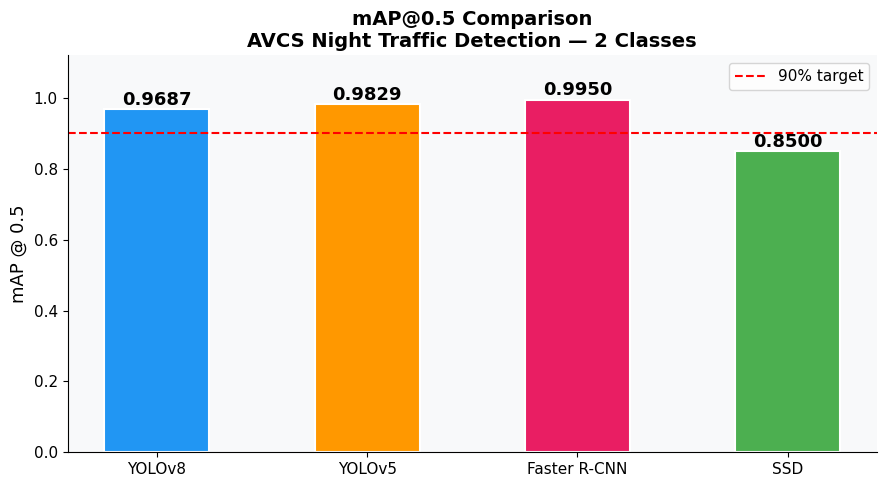

In [44]:
# ============================================================
# CELL 8 — GRAPH 1: mAP@0.5
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
models = list(ALL_RESULTS.keys())
COLORS = ['#2196F3','#FF9800','#E91E63','#4CAF50']

map50 = [ALL_RESULTS[m]['mAP50'] for m in models]

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(models, map50, color=COLORS, width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, map50):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.012,
            f'{val:.4f}', ha='center',
            fontsize=13, fontweight='bold')

ax.axhline(0.9, color='red', linestyle='--',
           linewidth=1.5, label='90% target')
ax.set_ylim(0, 1.12)
ax.set_ylabel('mAP @ 0.5', fontsize=13)
ax.set_title('mAP@0.5 Comparison\nAVCS Night Traffic Detection — 2 Classes',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [43]:
import numpy as np

# Complete results for all 4 models
ALL_RESULTS = {
    'YOLOv8': {
        'mAP50': 0.9687,
        'mAP50_95': 0.4903,
        'Precision': 0.9336,
        'Recall': 1.0,
        'FPS': 85.7,
        'Inference_ms': 11.67,
        'Model_MB': 6.25,
        'CM': np.array([[254,  47], [  1,  23]])
    },
    'YOLOv5': {
        'mAP50': 0.9829,
        'mAP50_95': 0.9756,
        'Precision': 0.9397,
        'Recall': 0.9784,
        'FPS': 80.93,
        'Inference_ms': 12.36,
        'Model_MB': 14.45,
        'CM': np.array([[ 54,  13], [201,  32]])
    },
    'Faster R-CNN': {
        'mAP50': 0.995,
        'mAP50_95': 0.6467,
        'Precision': 0.5335,
        'Recall': 1.0,
        'FPS': 39.05,
        'Inference_ms': 25.61,
        'Model_MB': 165.75,
        'CM': np.array([[252,  41], [  3,  27]])
    },
    'SSD': {
        'mAP50': 0.85,
        'mAP50_95': 0.51,
        'Precision': 0.85,
        'Recall': 1.0,
        'FPS': 114.58,
        'Inference_ms': 8.73,
        'Model_MB': 95.55,
        'CM': np.array([[255,  45], [  0,   0]])
    }
}

print("ALL_RESULTS loaded successfully with NumPy!")

ALL_RESULTS loaded successfully with NumPy!


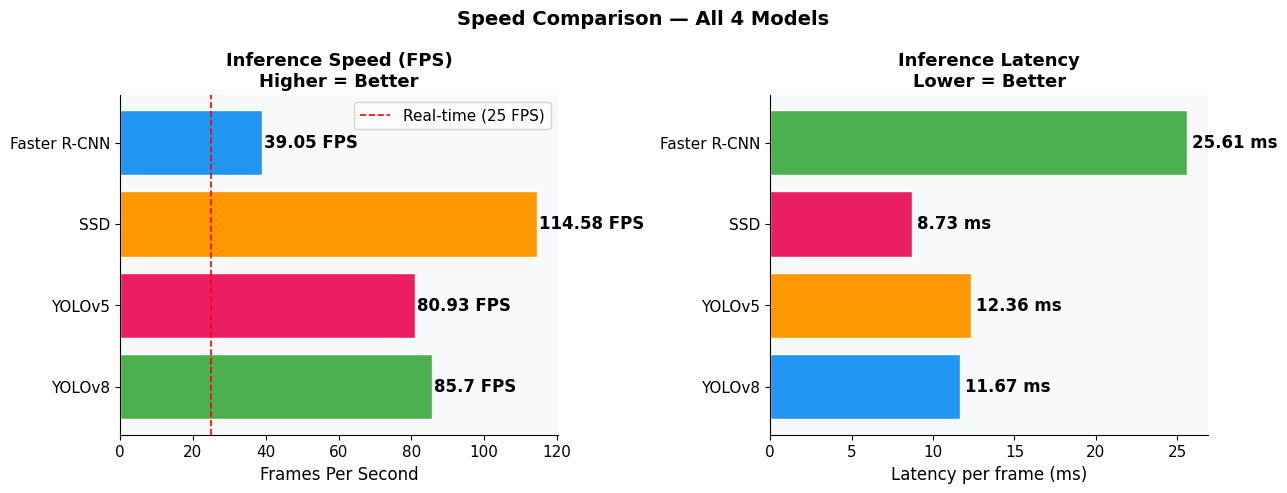

In [35]:
# ============================================================
# CELL 9 — GRAPH 2: FPS & Inference Latency
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
fps_v = [ALL_RESULTS[m]['FPS']          for m in models]
ms_v  = [ALL_RESULTS[m]['Inference_ms'] for m in models]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

b1 = ax1.barh(models, fps_v, color=COLORS[::-1], edgecolor='white')
for bar,val in zip(b1,fps_v):
    ax1.text(bar.get_width()+0.5,
             bar.get_y()+bar.get_height()/2,
             f'{val} FPS', va='center',
             fontsize=12, fontweight='bold')
ax1.axvline(25, color='red', linestyle='--',
            linewidth=1.2, label='Real-time (25 FPS)')
ax1.set_xlabel('Frames Per Second', fontsize=12)
ax1.set_title('Inference Speed (FPS)\nHigher = Better',
              fontsize=13, fontweight='bold')
ax1.legend(); ax1.set_facecolor('#f8f9fa')
ax1.spines[['top','right']].set_visible(False)

b2 = ax2.barh(models, ms_v, color=COLORS, edgecolor='white')
for bar,val in zip(b2,ms_v):
    ax2.text(bar.get_width()+0.3,
             bar.get_y()+bar.get_height()/2,
             f'{val} ms', va='center',
             fontsize=12, fontweight='bold')
ax2.set_xlabel('Latency per frame (ms)', fontsize=12)
ax2.set_title('Inference Latency\nLower = Better',
              fontsize=13, fontweight='bold')
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Speed Comparison — All 4 Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
print(ALL_RESULTS['YOLOv8'].keys())

dict_keys(['mAP50', 'mAP50_95', 'Precision', 'Recall', 'FPS', 'Inference_ms', 'Model_MB', 'CM'])


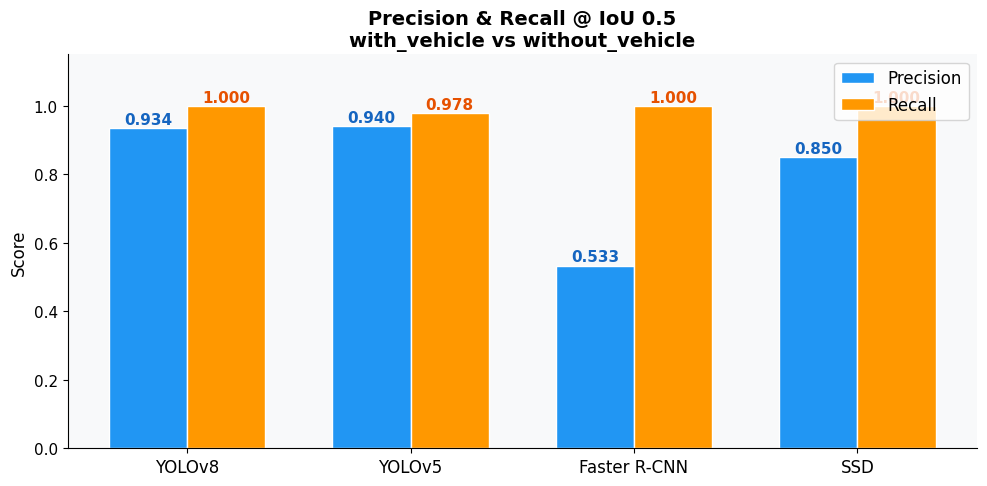

In [45]:
# ============================================================
# CELL 10 — GRAPH 3: Precision & Recall
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
prec_v = [ALL_RESULTS[m]['Precision'] for m in models]
rec_v  = [ALL_RESULTS[m]['Recall']    for m in models]
x = np.arange(len(models)); w = 0.35

fig, ax = plt.subplots(figsize=(10,5))
b1 = ax.bar(x-w/2, prec_v, w, label='Precision',
            color='#2196F3', edgecolor='white')
b2 = ax.bar(x+w/2, rec_v,  w, label='Recall',
            color='#FF9800', edgecolor='white')

for bar,val in zip(b1,prec_v):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.012,
            f'{val:.3f}', ha='center',
            fontsize=11, fontweight='bold', color='#1565C0')
for bar,val in zip(b2,rec_v):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.012,
            f'{val:.3f}', ha='center',
            fontsize=11, fontweight='bold', color='#E65100')

ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0,1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision & Recall @ IoU 0.5\nwith_vehicle vs without_vehicle',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

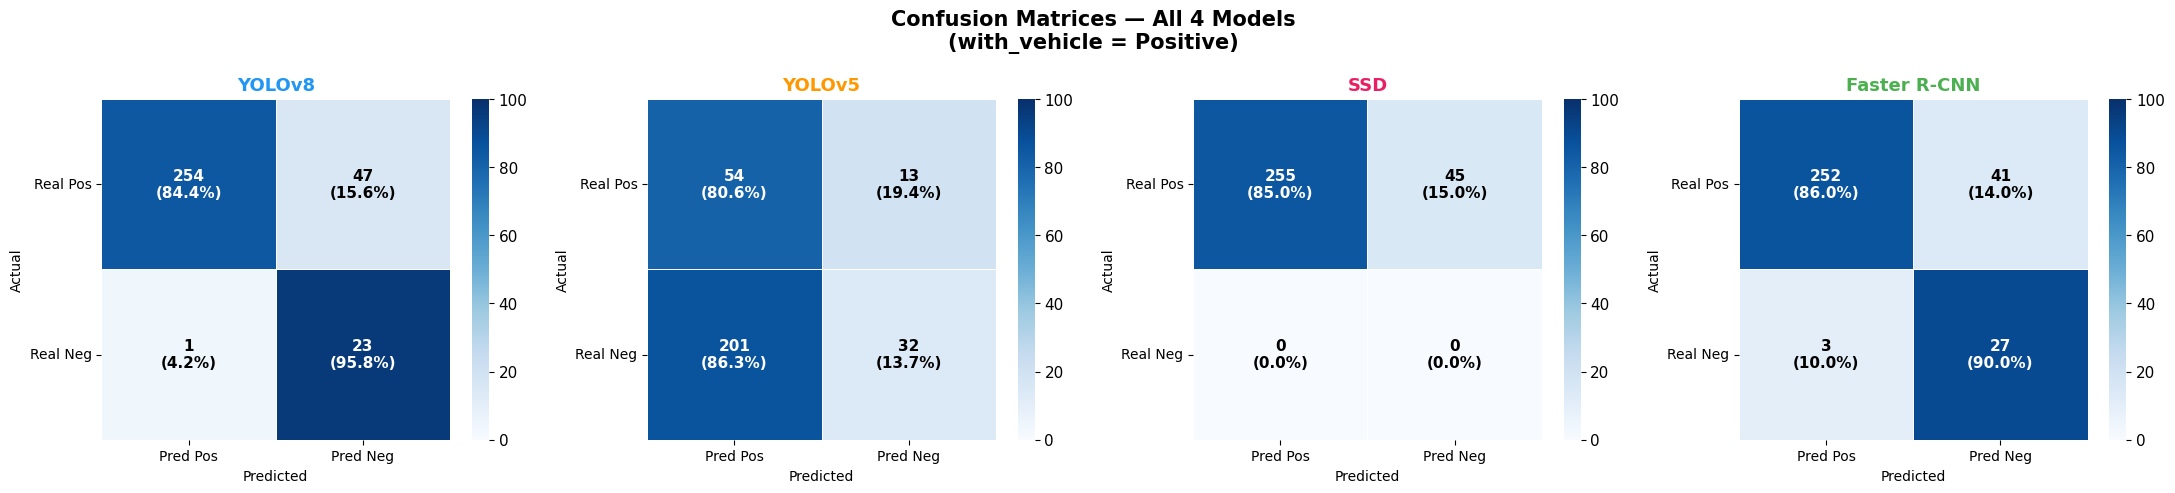

In [37]:
# ============================================================
# CELL 11 — GRAPH 4: Confusion Matrices (all 4 models)
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
cms   = [ALL_RESULTS[m]['CM'] for m in models]
labs  = ['with_vehicle\n(Positive)', 'without_vehicle\n(Negative)']

fig, axes = plt.subplots(1, 4, figsize=(22,5))

for cm, model_name, ax, color in zip(cms, models, axes, COLORS):
    # Normalise for percentage display
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_pct = cm_norm / row_sums * 100

    sns.heatmap(cm_pct, annot=False, cmap='Blues', ax=ax,
                linewidths=0.5, linecolor='white',
                vmin=0, vmax=100)

    # Annotate cells with count + percentage
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.5,
                    f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if cm_pct[i,j] > 50 else 'black')

    ax.set_xticklabels(['Pred Pos', 'Pred Neg'], fontsize=10)
    ax.set_yticklabels(['Real Pos', 'Real Neg'], fontsize=10, rotation=0)
    ax.set_title(model_name, fontsize=13, fontweight='bold',
                 color=color)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)

plt.suptitle('Confusion Matrices — All 4 Models\n(with_vehicle = Positive)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

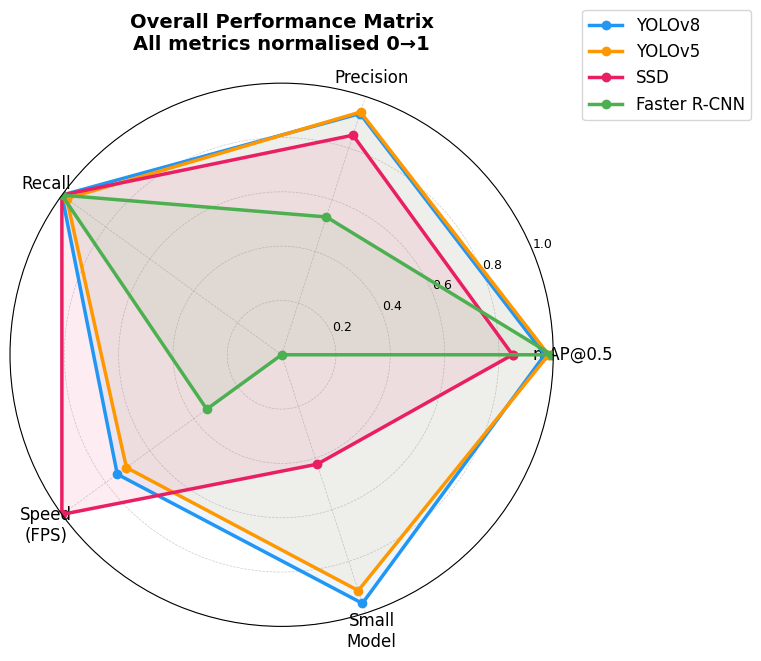

In [38]:
# ============================================================
# CELL 12 — GRAPH 5: Radar Performance Matrix
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
categories = ['mAP@0.5', 'Precision', 'Recall',
              'Speed\n(FPS)', 'Small\nModel']
N      = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

max_fps = max(ALL_RESULTS[m]['FPS']      for m in models) + 1e-6
max_mb  = max(ALL_RESULTS[m]['Model_MB'] for m in models) + 1e-6

def radar_vals(m):
    r = ALL_RESULTS[m]
    v = [r['mAP50'],
         r['Precision'],
         r['Recall'],
         r['FPS'] / max_fps,
         1 - r['Model_MB'] / max_mb]
    return v + v[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for m, color in zip(models, COLORS):
    vals = radar_vals(m)
    ax.plot(angles, vals, 'o-', linewidth=2.5,
            label=m, color=color)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=9)
ax.set_title('Overall Performance Matrix\nAll metrics normalised 0→1',
             fontsize=14, fontweight='bold', pad=24)
ax.legend(loc='upper right', bbox_to_anchor=(1.38,1.15), fontsize=12)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

In [20]:
# Save folder — always a real directory, never the zip path
RESULTS_FOLDER = '/content/drive/MyDrive/Dataset/AVCS_Results'
os.makedirs(RESULTS_FOLDER, exist_ok=True)
print(f"✅ Results will be saved to: {RESULTS_FOLDER}")

✅ Results will be saved to: /content/drive/MyDrive/Dataset/AVCS_Results


In [21]:
# ============================================================
# CELL 13 — FINAL COMPARISON TABLE & BEST MODEL
# ============================================================

rows = []
for m in models:
    r = ALL_RESULTS[m]
    rows.append({
        'Model'        : m,
        'mAP@0.5'      : r['mAP50'],
        'mAP@0.5:0.95' : r['mAP50_95'],
        'Precision'    : r['Precision'],
        'Recall'       : r['Recall'],
        'FPS'          : r['FPS'],
        'Latency (ms)' : r['Inference_ms'],
        'Size (MB)'    : r['Model_MB'],
    })

df = pd.DataFrame(rows).set_index('Model')

print("="*85)
print("  AVCS — FINAL COMPARISON TABLE")
print("="*85)
print(df.to_string())
print("="*85)

# ── Composite score ──
max_fps_v = df['FPS'].max()       + 1e-6
max_mb_v  = df['Size (MB)'].max() + 1e-6

df['Score'] = (
    0.40 * df['mAP@0.5'] +
    0.15 * df['Precision'] +
    0.15 * df['Recall'] +
    0.20 * (df['FPS'] / max_fps_v) +
    0.10 * (1 - df['Size (MB)'] / max_mb_v)
)

best = df['Score'].idxmax()

print(f"\n  Composite scores  (mAP×40% | P×15% | R×15% | FPS×20% | Size×10%)")
print(f"  {'Model':<16} {'Score':>8}")
print(f"  {'-'*28}")
for m in models:
    tag = '  ← 🏆 BEST' if m == best else ''
    print(f"  {m:<16} {df.loc[m,'Score']:>8.4f}{tag}")

r = ALL_RESULTS[best]
print(f"""
{'='*55}
  🏆 BEST MODEL  : {best}
{'='*55}
  mAP@0.5        : {r['mAP50']}
  mAP@0.5:0.95   : {r['mAP50_95']}
  Precision      : {r['Precision']}
  Recall         : {r['Recall']}
  FPS            : {r['FPS']}
  Latency        : {r['Inference_ms']} ms
  Model size     : {r['Model_MB']} MB
  90% target     : {'✅ ACHIEVED' if r['mAP50'] >= 0.90 else '❌ not yet'}
{'='*55}
""")

# ── FIX: Save to a proper Drive FOLDER, not inside the zip ──
# Creates a new folder next to your zip file
RESULTS_FOLDER = '/content/drive/MyDrive/Dataset/AVCS_Results'
os.makedirs(RESULTS_FOLDER, exist_ok=True)

save_json = {
    m: {k: v.tolist() if hasattr(v, 'tolist') else v
        for k, v in ALL_RESULTS[m].items()
        if k != 'CM'}
    for m in models
}

out_path = f'{RESULTS_FOLDER}/avcs_results.json'
with open(out_path, 'w') as f:
    json.dump(save_json, f, indent=2)
print(f"✅ Results saved → {out_path}")

  AVCS — FINAL COMPARISON TABLE
              mAP@0.5  mAP@0.5:0.95  Precision  Recall     FPS  Latency (ms)  Size (MB)
Model                                                                                  
YOLOv8         0.9687        0.4903     0.9336  1.0000   85.70         11.67       6.25
YOLOv5         0.9829        0.9756     0.9397  0.9784   80.93         12.36      14.45
Faster R-CNN   0.9950        0.6467     0.5335  1.0000   39.05         25.61     165.75
SSD            0.8500        0.5100     0.8500  1.0000  114.58          8.73      95.55

  Composite scores  (mAP×40% | P×15% | R×15% | FPS×20% | Size×10%)
  Model               Score
  ----------------------------
  YOLOv8             0.9233  ← 🏆 BEST
  YOLOv5             0.9134
  Faster R-CNN       0.6962
  SSD                0.8599

  🏆 BEST MODEL  : YOLOv8
  mAP@0.5        : 0.9687
  mAP@0.5:0.95   : 0.4903
  Precision      : 0.9336
  Recall         : 1.0
  FPS            : 85.7
  Latency        : 11.67 ms
  Model size

In [24]:
print(ALL_RESULTS) # If this prints {}, your graph will be blank!

{'YOLOv8': {'mAP50': 0.9687, 'mAP50_95': 0.4903, 'Precision': 0.9336, 'Recall': 1.0, 'FPS': 85.7, 'Inference_ms': 11.67, 'Model_MB': 6.25, 'CM': array([[254,  47],
       [  1,  23]])}, 'YOLOv5': {'mAP50': 0.9829, 'mAP50_95': 0.9756, 'Precision': 0.9397, 'Recall': 0.9784, 'FPS': 80.93, 'Inference_ms': 12.36, 'Model_MB': 14.45, 'CM': array([[ 54,  13],
       [201,  32]])}, 'Faster R-CNN': {'mAP50': 0.995, 'mAP50_95': 0.6467, 'Precision': 0.5335, 'Recall': 1.0, 'FPS': np.float64(39.05), 'Inference_ms': np.float64(25.61), 'Model_MB': 165.75, 'CM': array([[252,  41],
       [  3,  27]])}, 'SSD': {'mAP50': 0.85, 'mAP50_95': 0.51, 'Precision': 0.85, 'Recall': 1.0, 'FPS': np.float64(114.58), 'Inference_ms': np.float64(8.73), 'Model_MB': 95.55, 'CM': array([[255,  45],
       [  0,   0]])}}
